## 7.6 조던-위그너 변환으로 분자 해밀토니안을 큐비트 연산자에 매핑

In [1]:
# Qiskit 라이브러리 임포트
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, partial_trace
from qiskit.visualization import plot_bloch_multivector, plot_state_city, plot_state_qsphere, plot_histogram
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 양자회로 생성
n_qubits = 4  # 큐비트 수 정의
qc = QuantumCircuit(n_qubits)

In [3]:
# 일련의 게이트 적용 (고급 얽힘 및 변분 층)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.ry(0.7, 2)
qc.rz(0.8, 1)
qc.cx(2, 3)
qc.ry(0.5, 3)

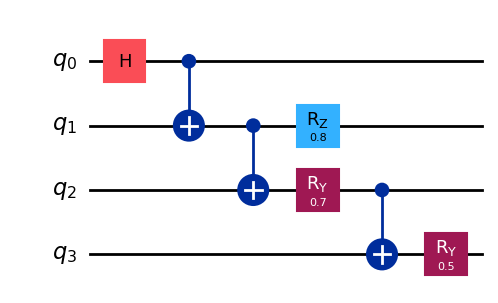

In [4]:
# 측정 추가 전 회로 그리기
qc.draw(output='mpl')  # MPL 회로 시각화
plt.show()

In [5]:
# AerSimulator로 상태벡터 시뮬레이션
simulator = AerSimulator()
state = Statevector.from_instruction(qc)

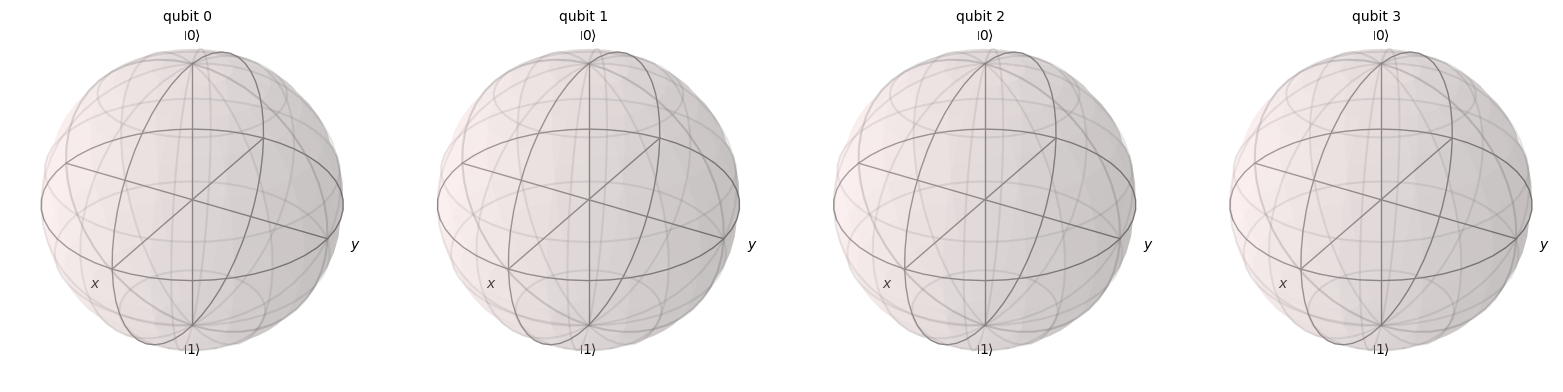

In [6]:
# 측정 전 시각화 생성
plot_bloch_multivector(state)
plt.show()

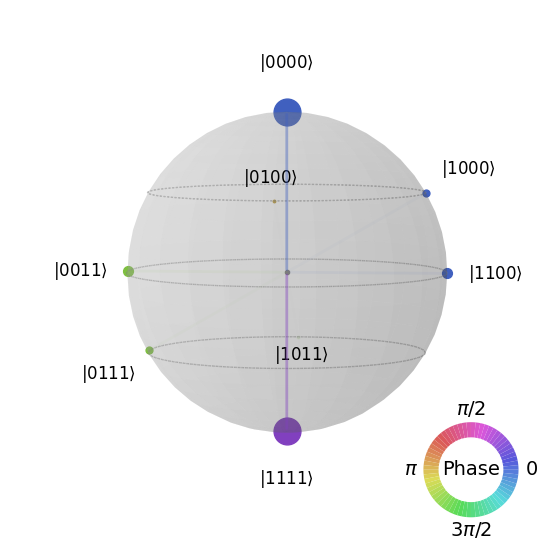

In [7]:
# QSphere 시각화: 양자 상태를 QSphere 위에 표현
plot_state_qsphere(state)
plt.show()

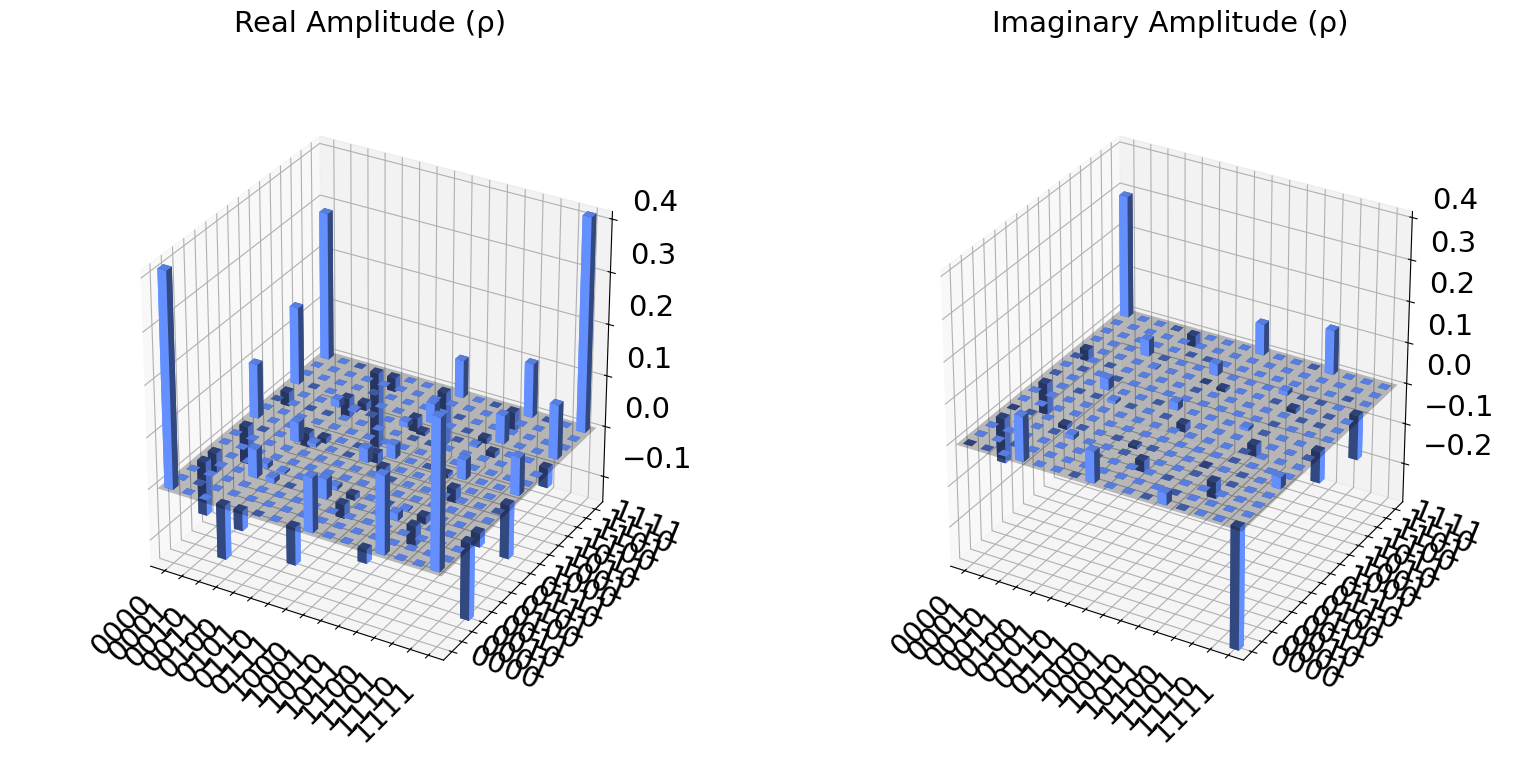

In [8]:
# State city 시각화: 양자 상태 밀도행렬의 3D 표현
plot_state_city(state)
plt.show()

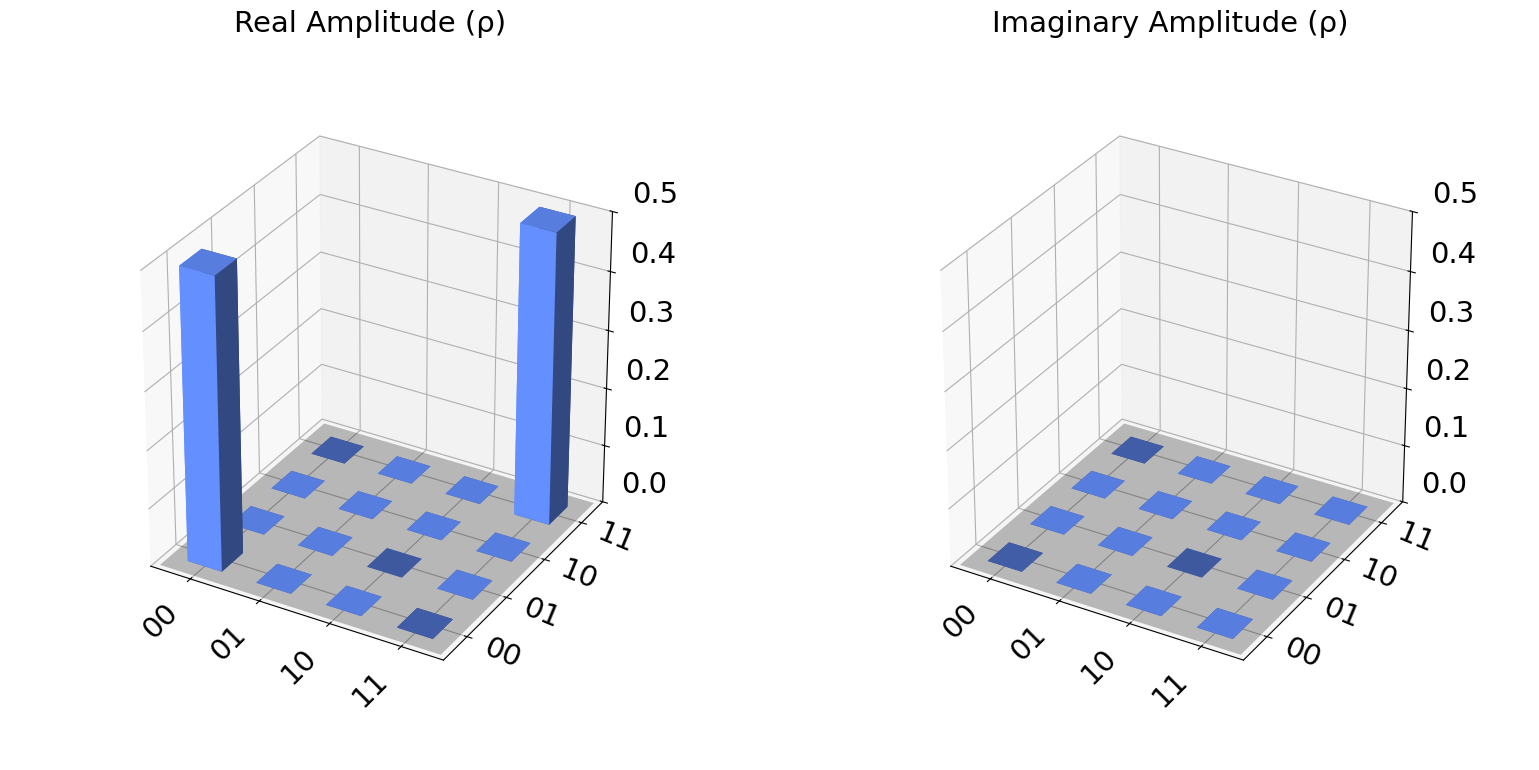

In [9]:
# 부분 대각합: 두 큐비트에 대한 축소 밀도행렬
rho = partial_trace(state, [2, 3])  # 큐비트 2, 3을 추적 제거
plot_state_city(rho)  # 부분 대각합 결과 시각화
plt.show()

In [10]:
# 이제 모든 큐비트에 측정 추가
qc.measure_all()

In [11]:
# AerSimulator로 측정 시뮬레이션
simulator = AerSimulator()
result = simulator.run(qc).result()
counts = result.get_counts()

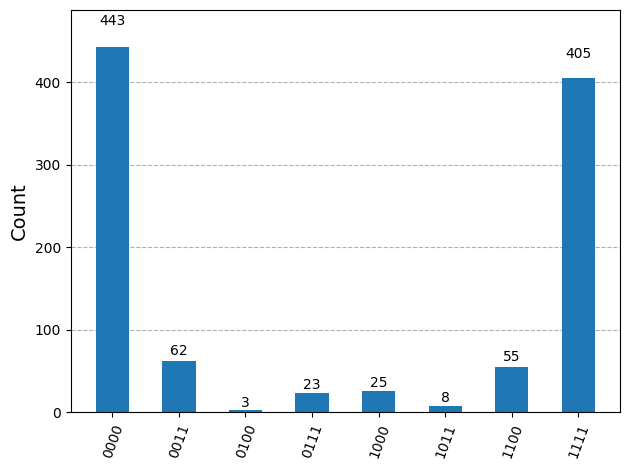

In [12]:
# 히스토그램: 측정 결과 시각화
plot_histogram(counts)
plt.show()

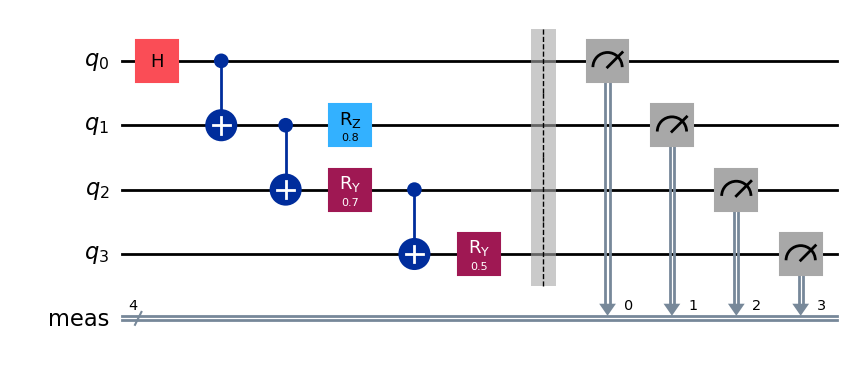

In [13]:
# 측정 추가 후 회로 그리기
qc.draw(output='mpl')  # MPL 회로 시각화
plt.show()